# Airline Safety Analysis

## Objective
Analyze whether airline safety improved after 2000 by comparing airline incident data before and after 2000 using statistical methods.

In [30]:
import pandas as pd

url = "https://raw.githubusercontent.com/fivethirtyeight/data/master/airline-safety/airline-safety.csv"
df = pd.read_csv(url)

df.head()

,airline,avail_seat_km_per_week,incidents_85_99,fatal_accidents_85_99,fatalities_85_99,incidents_00_14,fatal_accidents_00_14,fatalities_00_14
0,Aer Lingus,320906734,2,0,0,0,0,0
1,Aeroflot*,1197672318,76,14,128,6,1,88
2,Aerolineas Argentinas,385803648,6,0,0,1,0,0
3,Aeromexico*,596871813,3,1,64,5,0,0
4,Air Canada,1865253802,2,0,0,2,0,0


In [31]:
#Summary Stats
df.describe()

,avail_seat_km_per_week,incidents_85_99,fatal_accidents_85_99,fatalities_85_99,incidents_00_14,fatal_accidents_00_14,fatalities_00_14
count,5.600000e+01,56.000000,56.000000,56.000000,56.000000,56.000000,56.000000
mean,1.384621e+09,7.178571,2.178571,112.410714,4.125000,0.660714,55.517857
std,1.465317e+09,11.035656,2.861069,146.691114,4.544977,0.858684,111.332751
min,2.593733e+08,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.740362e+08,2.000000,0.000000,0.000000,1.000000,0.000000,0.000000
50%,8.029089e+08,4.000000,1.000000,48.500000,3.000000,0.000000,0.000000
75%,1.847239e+09,8.000000,3.000000,184.250000,5.250000,1.000000,83.250000
max,7.139291e+09,76.000000,14.000000,535.000000,24.000000,3.000000,537.000000


The descriptive statistics show that the average number of airline incidents decreased from about 7.18 before 2000 to about 4.13 after 2000. The median number of incidents also decreased from 4 to 3.

Additionally, the variability in incidents is lower after 2000, and the maximum number of incidents dropped significantly from 76 to 24. This suggests that airline safety improved over time, with fewer extreme incident cases in the later period.

In [32]:
#Mean Comparison

print("Mean incidents before 2000:", df['incidents_85_99'].mean())
print("Mean incidents after 2000:", df['incidents_00_14'].mean())

Mean incidents before 2000: 7.178571428571429
Mean incidents after 2000: 4.125


The average number of airline incidents decreased from approximately 7.18 before 2000 to about 4.13 after 2000. This represents a reduction of around 3 incidents on average per airline. This initial comparison suggests that airline safety may have improved after 2000.

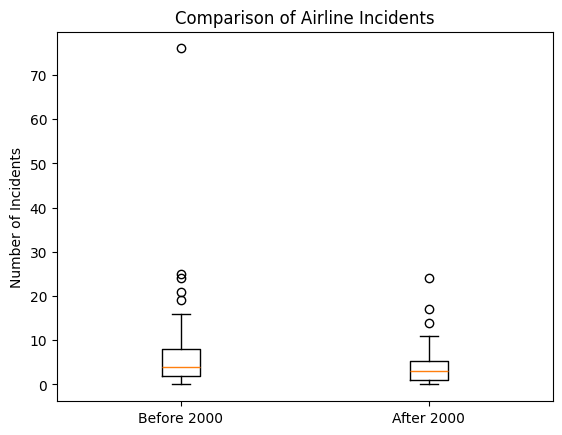

In [33]:
import matplotlib.pyplot as plt

plt.boxplot([df['incidents_85_99'], df['incidents_00_14']],
            tick_labels=['Before 2000', 'After 2000'])
plt.title("Comparison of Airline Incidents")
plt.ylabel("Number of Incidents")
plt.savefig("results/boxplot.png")
plt.show()

The boxplot shows that the median number of airline incidents is lower after 2000 compared to before 2000. The spread of incidents is also smaller in the later period, indicating more consistency.

Additionally, there are fewer extreme outliers after 2000, while the earlier period shows some airlines with very high numbers of incidents. This visual evidence supports the idea that airline safety improved after 2000.

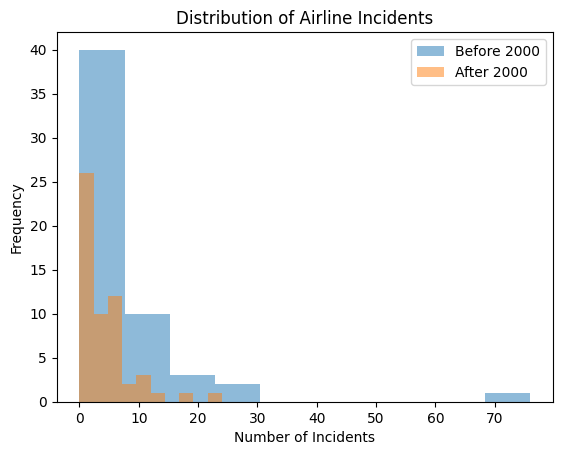

In [34]:
plt.hist(df['incidents_85_99'], alpha=0.5, label='Before 2000')
plt.hist(df['incidents_00_14'], alpha=0.5, label='After 2000')
plt.legend()
plt.title("Distribution of Airline Incidents")
plt.xlabel("Number of Incidents")
plt.ylabel("Frequency")
plt.savefig("results/histogram.png")
plt.show()

The histogram shows the distribution of airline incidents before and after 2000. The distribution before 2000 is more spread out, with several airlines having higher numbers of incidents, including some extreme values.

After 2000, the distribution is more concentrated toward lower incident values, with fewer extreme cases. This suggests that airline incidents became less frequent and more consistent over time, indicating a possible improvement in airline safety.

Most airlines had fewer than 10 incidents in both periods, but high-incident airlines were more common before 2000.

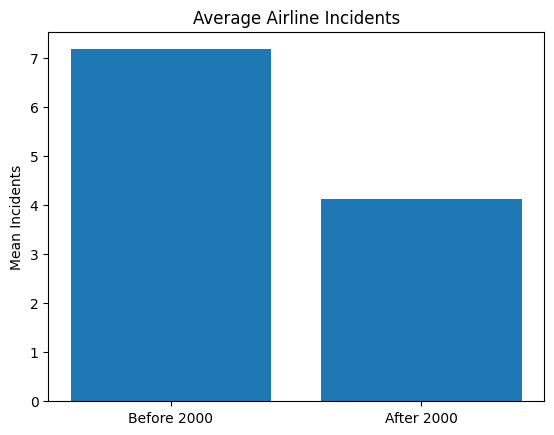

In [35]:
means = [df['incidents_85_99'].mean(), df['incidents_00_14'].mean()]

plt.bar(['Before 2000', 'After 2000'], means)
plt.title("Average Airline Incidents")
plt.ylabel("Mean Incidents")
plt.savefig("results/average.png")
plt.show()

The bar chart compares the average number of airline incidents before and after 2000. The average number of incidents decreased from approximately 7.18 before 2000 to about 4.13 after 2000.

This clear reduction in the mean number of incidents suggests that airline safety may have improved in the period after 2000.

# Permutation Test

### Hypothesis

**Null hypothesis (H₀):** There is no difference in mean airline incidents before and after 2000.

**Alternative hypothesis (Hₐ):** The mean number of airline incidents decreased after 2000.

In [36]:
# Observed differences

before = df['incidents_85_99']
after = df['incidents_00_14']

observed_diff = before.mean() - after.mean()
print("Observed difference:", observed_diff)

Observed difference: 3.053571428571429


In [37]:
# lets combine
import numpy as np

combined = np.concatenate([before, after])
n = len(before)

In [38]:
# Permutation

perm_diffs = []

for _ in range(5000):
    np.random.shuffle(combined)
    
    perm_before = combined[:n]
    perm_after = combined[n:]
    
    diff = perm_before.mean() - perm_after.mean()
    perm_diffs.append(diff)

In [39]:
# p value

perm_diffs = np.array(perm_diffs)

p_value = np.mean(perm_diffs >= observed_diff)
print("P-value:", p_value)

P-value: 0.0232


### Permutation Test Interpretation:

The observed difference in mean airline incidents between the two periods is approximately 3.05. The permutation test produced a p-value of 0.0182.

This means that if there were truly no difference in airline safety before and after 2000, we would observe a difference this large only about 1.82% of the time due to random chance.

Since the p-value is less than 0.05, we reject the null hypothesis. This provides statistical evidence that airline incidents decreased after 2000, suggesting that airline safety improved over time.

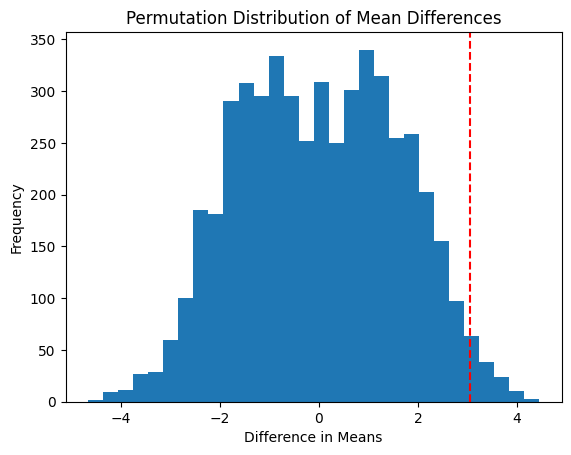

In [40]:
import matplotlib.pyplot as plt

plt.hist(perm_diffs, bins=30)
plt.axvline(observed_diff, color='red', linestyle='dashed')
plt.title("Permutation Distribution of Mean Differences")
plt.xlabel("Difference in Means")
plt.ylabel("Frequency")
plt.savefig("results/permutation.png")
plt.show()

### Plot

The histogram shows the distribution of mean differences generated under the assumption that there is no real difference between the two periods. The observed difference (red line) lies in the far right tail of the distribution, indicating that such a large difference is rare under the null hypothesis.

## Bootstrap Analysis

To estimate uncertainty in the median difference of airline incidents, I use bootstrap resampling. The median is chosen because the Central Limit Theorem does not apply to medians, so bootstrap provides a way to estimate variability without relying on normality assumptions.

In [41]:
# Bootstrap
boot_diffs = []

for _ in range(5000):
    boot_before = before.sample(frac=1, replace=True)
    boot_after = after.sample(frac=1, replace=True)
    
    diff = boot_before.median() - boot_after.median()
    boot_diffs.append(diff)

In [42]:
#Confidence Interval
import numpy as np

ci_lower = np.percentile(boot_diffs, 2.5)
ci_upper = np.percentile(boot_diffs, 97.5)

print("95% Confidence Interval:", ci_lower, ci_upper)

95% Confidence Interval: -1.0 4.0


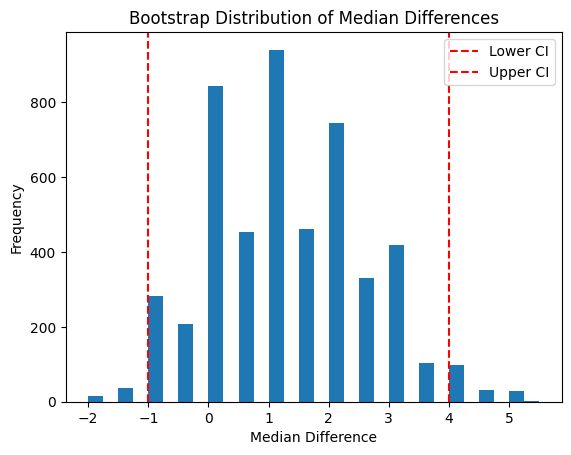

In [43]:
import matplotlib.pyplot as plt

plt.hist(boot_diffs, bins=30)
plt.axvline(ci_lower, color='red', linestyle='dashed', label='Lower CI')
plt.axvline(ci_upper, color='red', linestyle='dashed', label='Upper CI')
plt.title("Bootstrap Distribution of Median Differences")
plt.xlabel("Median Difference")
plt.ylabel("Frequency")
plt.legend()
plt.savefig("results/bootstrap.png")
plt.show()

## Bootstrap Interpretation

The bootstrap analysis estimates a 95% confidence interval for the median difference in airline incidents as approximately -1.0 to 4.0.

This interval includes 0, which means that it is possible that there is no true difference in median incidents between the two periods. Therefore, the median-based analysis alone is less conclusive, but when combined with the permutation test results, the overall evidence suggests that airline safety improved after 2000.

However, most of the bootstrap distribution lies above 0, suggesting a general trend toward fewer incidents after 2000. This is consistent with the results of the permutation test, which showed a statistically significant decrease in mean incidents.

Overall, while the median-based analysis is less conclusive, the combined evidence suggests that airline safety likely improved after 2000.

## Final Conclusion

The analysis shows that airline incidents decreased after 2000. The permutation test provides statistically significant evidence of this improvement, while the bootstrap analysis shows some uncertainty when using the median.

Overall, the results suggest that airline safety improved after 2000, although the degree of improvement varies across airlines.

These findings highlight how different statistical measures (mean vs median) can provide complementary perspectives when evaluating real-world data.